**Objective**: Implement and compare linear regression and logistic regression for binary classification. Construct a robust machine learning pipeline and evaluate the impact of classification thresholds on model performance.

**Learning Goals**:
- Understand the limitations of linear models for classification tasks.
- Implement a scikit-learn `Pipeline` integrating `StandardScaler`, `SelectKBest`, and `LogisticRegression`.
- Extract raw probabilities using `predict_proba()`.
- Analyze the trade-off between Precision and Recall by manipulating decision thresholds.

## Step 1: Import Libraries and Setup
Import necessary modules for data manipulation, modeling, evaluation, and visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

# Bypass SSL certificate verification for dataset downloads
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## Step 2: Generate 1D Toy Dataset & Inject Outlier
Create a synthetic 1D dataset representing "Hours Studied" versus a binary "Pass/Fail" outcome. An extreme outlier is intentionally included to highlight a core vulnerability in linear models.

In [5]:
np.random.seed(42)
X_toy = np.sort(np.random.uniform(0, 10, 20)).reshape(-1, 1)
y_toy = (X_toy[:, 0] > 5).astype(int)

# Inject an extreme outlier
X_toy = np.vstack([X_toy, [[50]]])
y_toy = np.append(y_toy, [1])

print("Toy dataset generated with shape:", X_toy.shape)

Toy dataset generated with shape: (21, 1)


## Step 3: Fit Linear Regression on Toy Dataset
Train a standard linear regression model on the classification data.

In [6]:
# TODO: Initialize a LinearRegression model
lin_model = LinearRegression()

# TODO: Fit the model to X_toy and y_toy
lin_model.fit(X_toy, y_toy)

# TODO: Generate predictions using the fitted linear model
y_lin_pred = lin_model.predict(X_toy)

## Step 4: Visualize Linear Regression Limitations
Plot the original data points and the linear regression line. Observe how the outlier pulls the line, causing standard data points to be misclassified when using a 0.5 boundary. Also note that predictions fall outside the [0, 1] probability range.

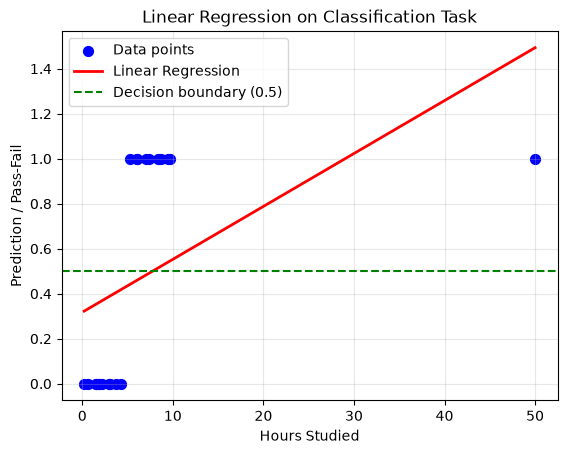

In [7]:
# TODO: Plot the original data points (scatter plot)
plt.scatter(X_toy, y_toy, color='blue', label='Data points', s=50)

# TODO: Plot the linear regression line using y_lin_pred
plt.plot(X_toy, y_lin_pred, color='red', label='Linear Regression', linewidth=2)

# TODO: Add a horizontal line at 0.5 to represent the decision boundary
plt.axhline(y=0.5, color='green', linestyle='--', label='Decision boundary (0.5)')

# TODO: Add labels, a title, and a legend, then display the plot
plt.xlabel('Hours Studied')
plt.ylabel('Prediction / Pass-Fail')
plt.title('Linear Regression on Classification Task')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 5: Fit Logistic Regression on Toy Dataset
Train a logistic regression model on the exact same dataset to compare resilience against outliers.

In [8]:
# TODO: Initialize a LogisticRegression model (set random_state=42)
log_model = LogisticRegression(random_state=42)

# TODO: Fit the model to X_toy and y_toy
log_model.fit(X_toy, y_toy)

# Generate a dense range of X values for a smooth curve
X_smooth = np.linspace(0, 50, 300).reshape(-1, 1)

# TODO: Extract the probability predictions for the positive class (class 1) 
# using predict_proba() on X_smooth
y_log_prob = log_model.predict_proba(X_smooth)[:, 1]

## Step 6: Visualize Logistic Regression Resilience
Plot the logistic regression sigmoid curve. Observe how it bounds predictions between 0 and 1, maintaining an accurate decision boundary despite the outlier.

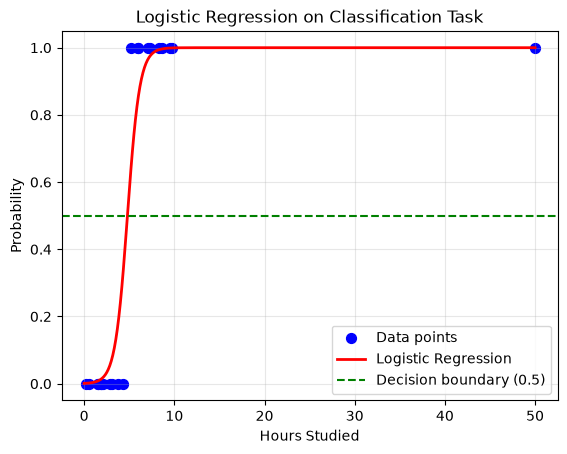

In [9]:
# TODO: Plot the original data points (scatter plot)
plt.scatter(X_toy, y_toy, color='blue', label='Data points', s=50)

# TODO: Plot the logistic regression sigmoid curve using y_log_prob
plt.plot(X_smooth, y_log_prob, color='red', label='Logistic Regression', linewidth=2)

# TODO: Add a horizontal line at 0.5 to represent the probability boundary
plt.axhline(y=0.5, color='green', linestyle='--', label='Decision boundary (0.5)')

# TODO: Add labels, a title, and a legend, then display the plot
plt.xlabel('Hours Studied')
plt.ylabel('Probability')
plt.title('Logistic Regression on Classification Task')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 7: Load Real-World Dataset
Load the Wine Quality dataset and create a binary target variable to evaluate the full pipeline.

In [10]:
def load_wine_quality():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    data = pd.read_csv(url, sep=';')
    # Create binary target: 1 if quality > 5, else 0
    data['good_quality'] = (data['quality'] > 5).astype(int)
    X = data.drop(['quality', 'good_quality'], axis=1)
    y = data['good_quality']
    
    return train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = load_wine_quality()
print("Training data shape:", X_train.shape)

Training data shape: (1119, 11)


## Step 8: Construct Machine Learning Pipeline
Build a scikit-learn Pipeline with feature scaling, feature selection, and the logistic regression classifier.

In [11]:
# TODO: Build a scikit-learn Pipeline with three steps:
# 1. 'scaler': StandardScaler()
# 2. 'feature_selection': SelectKBest(f_classif, k=8)
# 3. 'classifier': LogisticRegression(random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(f_classif, k=8)),
    ('classifier', LogisticRegression(random_state=42))
])

# TODO: Fit the pipeline on the training data (X_train, y_train)
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['fixed acidity','volatile acidity','citric acid',...,'pH','sulphates', 'alcohol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Step 9: Predict Probabilities and Evaluate Thresholds
Extract raw prediction probabilities. Manually apply custom thresholds (0.3, 0.5, 0.7) to evaluate how shifting the decision boundary affects the Confusion Matrix, Precision, and Recall.


EVALUATION AT THRESHOLD: 0.3
Accuracy:  0.7000
Precision: 0.6565
Recall:    0.9222
F1-Score:  0.7670


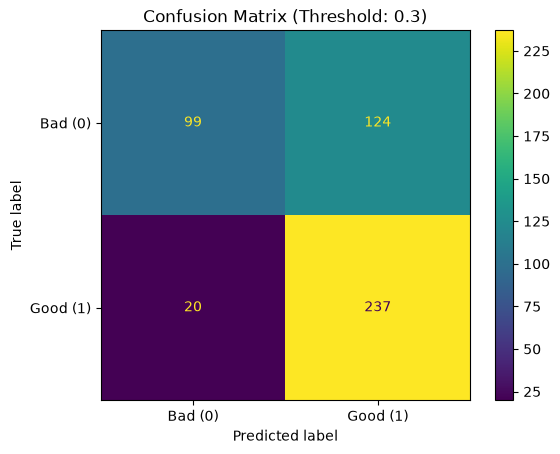


EVALUATION AT THRESHOLD: 0.5
Accuracy:  0.7312
Precision: 0.7520
Recall:    0.7432
F1-Score:  0.7476


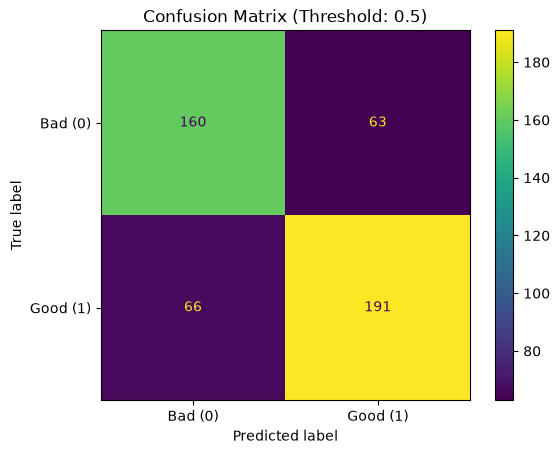


EVALUATION AT THRESHOLD: 0.7
Accuracy:  0.6937
Precision: 0.8526
Recall:    0.5175
F1-Score:  0.6441


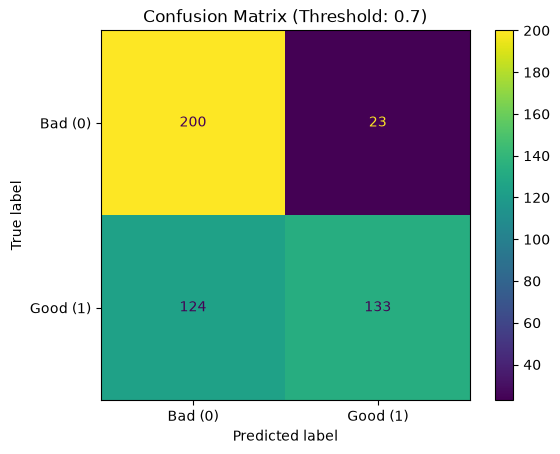

In [12]:
# TODO: Extract raw probabilities for the positive class (class 1) using predict_proba() on X_test
y_probs = pipeline.predict_proba(X_test)[:, 1]

# Define custom classification thresholds
thresholds = [0.3, 0.5, 0.7]

for thresh in thresholds:
    print(f"\n{'='*40}")
    print(f"EVALUATION AT THRESHOLD: {thresh}")
    print(f"{'='*40}")
    
    # TODO: 1. Generate binary predictions (1 if probability >= thresh, else 0)
    y_pred = (y_probs >= thresh).astype(int)
    
    # TODO: 2. Calculate and print Accuracy, Precision, Recall, and F1-Score
    # (Remember to set zero_division=0 for Precision and Recall)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # TODO: 3. Generate the Confusion Matrix and display it using ConfusionMatrixDisplay
    # (Optional: set display_labels=["Bad (0)", "Good (1)"] for clarity)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Bad (0)", "Good (1)"])
    disp.plot()
    plt.title(f'Confusion Matrix (Threshold: {thresh})')
    plt.show()